# Lab 2 — Spark execution: partitions, shuffles and the UI

Five exercises on how Spark actually runs a job: how work is split into partitions, which
operations force data to move across the cluster, and how to read the evidence for both in
the Spark UI.

**Setup:** `getting_started/local_setup_mac.md` (or `local_setup_windows.md`), then from the
repo root:

```sh
uv sync
uv run python get_data.py --dataset taxi
uv run jupyter lab          # then open labs/L2/lab.ipynb
```

VS Code works too — open this notebook and pick `.venv/bin/python` as the kernel.

Run the cells in order. Exercises 3 and 5 send you to the Spark UI, which only exists while
the session is alive, so leave the final `spark.stop()` cell until you have captured both
screenshots.

The code is mostly given; the **written answers** are what is marked.

In [1]:
import os

In [2]:
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] += r";C:\hadoop\bin"

In [3]:
import contextlib
import io
import os
import subprocess
import sys
import time
from pathlib import Path


def find_repo_root() -> Path:
    """The directory holding get_data.py, searching upward from the working directory.

    A kernel starts in the notebook's own directory (labs/L2/), so walk up rather than
    assuming anything about where you launched Jupyter from.
    """
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "get_data.py").exists():
            return candidate
    raise RuntimeError("Could not find the repo root — open this notebook from inside the repo.")


# Everything below assumes the repo root as the working directory: the dataset path, and the
# spark-warehouse/ and metastore_db/ directories Spark creates next to it. Move there once,
# here, before Spark starts.
os.chdir(find_repo_root())
print(f"working directory: {Path.cwd()}")

# A kernel started from an IDE never sources your shell profile, so JAVA_HOME can be missing
# here even though `java -version` works fine in a terminal. Resolve it before PySpark loads.
if "JAVA_HOME" not in os.environ:
    if sys.platform == "darwin":
        os.environ["JAVA_HOME"] = subprocess.check_output(["brew", "--prefix", "openjdk@17"], text=True).strip()
    else:
        raise RuntimeError("Set JAVA_HOME for your user account, then restart the kernel.")
os.environ["PATH"] = os.path.join(os.environ["JAVA_HOME"], "bin") + os.pathsep + os.environ.get("PATH", "")
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)

# Imported after the block above on purpose: PySpark looks for the JVM at import time.
from pyspark.sql import SparkSession  # noqa: E402
from pyspark.sql import functions as F  # noqa: E402

working directory: c:\Users\Boss\pyspark-demo


In [4]:
# local[4] rather than local[*]: this lab measures parallelism, so the number of slots has
# to be a number you know rather than "however many cores this laptop has".
CORES = 4

spark = (
    SparkSession.builder.appName("L2-execution")
    .master(f"local[{CORES}]")
    # A persistent catalog (a local Derby metastore under metastore_db/). Without it Spark
    # forgets its tables when the kernel dies but leaves their files in spark-warehouse/,
    # and the *second* run of this notebook fails with LOCATION_ALREADY_EXISTS.
    .enableHiveSupport()
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark {spark.version}, master {spark.sparkContext.master}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")


def physical_plan(df) -> str:
    """The physical plan as text.

    `df.explain()` prints to stdout rather than returning a string, so capture it. Using the
    public API keeps this lab to vanilla PySpark — no reaching into `df._jdf`.
    """
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        df.explain()
    return buf.getvalue()

Spark 4.2.0, master local[4]
Spark UI: http://DESKTOP-ODP3KL6:4040


## Setup — build the working table

One month of NYC taxi trips, read from Parquet and saved as a local table.

In [5]:
# Let's turn off adaptive query execution (AQE) for now — Exercise 4 turns it back on and
# measures what it changes. With AQE off, one action is one job, which makes the Spark UI
# far easier to read while you are still learning to navigate it.
spark.conf.set("spark.sql.adaptive.enabled", False)

In [6]:
# Relative to the repo root, which the setup cell made the working directory.
SRC = "data/yellow_tripdata_2023-01.parquet"
if not Path(SRC).exists():
    raise SystemExit(f"Missing {SRC}\nRun: uv run python get_data.py --dataset taxi")

# Name the work so it is identifiable in the Spark UI. The label sticks to every job this
# kernel starts until it is changed, so each cell below sets its own.
spark.sparkContext.setJobDescription("Setup: read trips data")

raw = spark.read.parquet(SRC)

trips = raw.select(
    F.col("tpep_pickup_datetime").cast("timestamp").alias("pickup_ts"),
    F.col("passenger_count").cast("int").alias("passenger_count"),
    F.col("trip_distance").cast("double").alias("trip_distance"),
    F.col("fare_amount").cast("double").alias("fare_amount"),
    F.col("tip_amount").cast("double").alias("tip_amount"),
    F.col("payment_type").cast("int").alias("payment_type"),
    F.col("PULocationID").cast("int").alias("pu_location_id"),
)

Navigate to Spark UI, we should see now one job. And you may say, well, but spark is lazy, how that is possible? 
The answer is because spark.read.parquet() has to return a DataFrame that already knows its columns — and finding them out requires reading the file. Laziness applies to data, not to metadata.

Next, let's examine the effect of *how* the data is saved. First we let Spark decide the layout, then we force it into 8 pieces, and we compare the two.

In [7]:
spark.sparkContext.setJobDescription("Setup: prepare trips default table")
spark.sql("DROP TABLE IF EXISTS trips")

spark.sparkContext.setJobDescription("Setup: save trips data as table")
trips.write.mode("overwrite").saveAsTable("trips")

In [8]:
spark.sparkContext.setJobDescription("Setup: prepare trips_repartitioned table")
spark.sql("DROP TABLE IF EXISTS trips_repartitioned")

spark.sparkContext.setJobDescription("Setup: save trips data as table (repartitioned to 8 partitions)")
trips.repartition(8).write.mode("overwrite").saveAsTable("trips_repartitioned")

In [9]:
from pyspark_demo.utils import get_tbl_partitions_summary


spark.sparkContext.setJobDescription("Inspect: rows per file in trips table")
_ = get_tbl_partitions_summary("trips")


trips  (\C:\Users\Boss\pyspark-demo\spark-warehouse\trips)
  on disk: 1 file(s), 35,958,399 bytes
    file                  bytes          rows
    part-00001       35,958,399     3,066,766

  read back: 4 partition(s), 3,066,766 rows
    partition            rows   reads     
    0                       0   -          
    1               3,066,766   part-00001 ################################
    2                       0   -          
    3                       0   -          
    -> 3 empty partition(s): slots that will be scheduled and do no work


In [10]:
spark.sparkContext.setJobDescription("Inspect: rows per file in trips_repartitioned table")
_ = get_tbl_partitions_summary("trips_repartitioned")


trips_repartitioned  (\C:\Users\Boss\pyspark-demo\spark-warehouse\trips_repartitioned)
  on disk: 8 file(s), 44,800,177 bytes
    file                  bytes          rows
    part-00006        5,600,050       383,346
    part-00003        5,603,029       383,346
    part-00005        5,596,506       383,346
    part-00004        5,596,577       383,346
    part-00000        5,597,984       383,345
    part-00002        5,603,625       383,346
    part-00001        5,599,698       383,345
    part-00007        5,602,708       383,346

  read back: 4 partition(s), 3,066,766 rows
    partition            rows   reads                 
    0                 766,692   part-00002, part-00003 ########
    1                 766,692   part-00006, part-00007 ########
    2                 766,690   part-00000, part-00001 ########
    3                 766,692   part-00004, part-00005 ########


The two reports don't agree, and that's the point. Files and partitions are set by two different mechanisms that never consult each other. The write chose 8 (you asked for repartition(8)). The read recomputes from scratch: it ignores how many files there are and packs them into splits sized for the cluster. Here that packing puts exactly two files in each split.

## Exercise 1 — Partitions and parallelism

A partition is the unit of work. A slot processes one partition at a time.

Too few partitions: slots sit idle. Too many: you pay scheduling overhead per task and
produce a pile of tiny output files.

**Before you run anything**, write down your prediction: as partition count goes
1 → 8 → 64 → 512 → 4096, what shape does the runtime curve have?

**Your prediction:**

I think it will be a U shape. 1 partition leaves 3 of the 4 slots idle, so it should be slow. The best should be around 4-8 partitions, one or two per core. After that it should get slower again, because the dataset is small and the overhead of scheduling thousands of tiny tasks will take over.

In [14]:
def timed_agg(n_partitions: int) -> float:
    """Repartition, run a fixed aggregation, return wall-clock seconds."""
    # Name each run after its partition count. Without this the five runs are identical in
    # the Spark UI and you cannot tell which job produced which timing.
    spark.sparkContext.setJobDescription(f"Ex1: repartition({n_partitions}) then aggregate")
    t0 = time.time()
    (
        trips.repartition(n_partitions)
        .groupBy("payment_type")
        .agg(F.avg("fare_amount"))
        .write.format("noop")
        .mode("overwrite")
        .save()  # forces execution, writes nothing
    )
    return time.time() - t0


# Drop the last one or two values if your laptop is slow — the shape is what matters.
SWEEP = [1, 8, 64, 512, 4096]

results = []
for n in SWEEP:
    secs = timed_agg(n)
    results.append((n, round(secs, 2)))
    print(f"{n:>5} partitions -> {secs:6.2f} s")

    1 partitions ->   0.97 s
    8 partitions ->   3.00 s
   64 partitions ->   3.78 s
  512 partitions ->   9.84 s
 4096 partitions ->  61.73 s


In [ ]:
spark.sparkContext.setJobDescription("Ex1: summary of the partition sweep")
spark.createDataFrame(results, "partitions int, seconds double").show()

**Q1a.** Was your prediction right? Your curve almost certainly has its minimum at the
*smallest* partition count and climbs from there — no dip in the middle. Explain why, using
what cells 9–11 told you about how this data is laid out on disk. What would have to be
different — about the data, or about the work done per row — for more partitions to win?

**Answer.** Only partly. More partitions did get slower, but 1 partition was the fastest (about 1s, then 8: ~3 s, 64: ~4s, 512: ~11 s, 4096: ~60-70 s), so there was no dip.

The reason is the data layout. `trips` is one ~36 MB file with 3M rows, and cell 11 shows that all rows are read by a single partition (the other 3 are empty). So the scan can't be parallelised, and `repartition(n)` only adds a full shuffle and n extra tasks after it. The aggregation itself is cheap (only a few `payment_type` values), so there is no work for extra partitions to share, and each task costs a fixed ~10-15 ms of overhead.

More partitions would win with much more data (many files, GBs), or with expensive work per row (e.g. a Python UDF), so that the compute per task is bigger than the scheduling overhead.

**Q1b.** `spark.sql.shuffle.partitions` defaults to 200. Print it below. Given your
measurements, is 200 sensible for *this* dataset on *this* machine? What would you set it
to, and what information did you need that the default could not have?

**Answer.** No. There are only 4 cores and about 5 distinct keys, so most of the 200 shuffle tasks are empty but still get scheduled (I saw the 200-task stage in every run). I would set it to 4-8, i.e. 1-2x the number of cores. To choose that I needed to know the number of cores, the size of the shuffled data and the number of keys, and the default can't know any of these.

In [15]:
print("shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("cores available to this session:", CORES)

shuffle partitions: 200
cores available to this session: 4


## Exercise 2 — Narrow vs wide

Classify each of the six operations below as **narrow** (no data moves between executors)
or **wide** (a shuffle). Fill in your answer *first*, then run the verification cell.

In [16]:
# TODO: replace each None with "narrow" or "wide"
answers = {
    "filter": "narrow",
    "withColumn": "narrow",
    "groupBy+agg": "wide",
    "orderBy": "wide",
    "select": "narrow",
    "dropDuplicates": "wide",
}
answers

{'filter': 'narrow',
 'withColumn': 'narrow',
 'groupBy+agg': 'wide',
 'orderBy': 'wide',
 'select': 'narrow',
 'dropDuplicates': 'wide'}

In [17]:
ops = {
    "filter": trips.filter(F.col("fare_amount") > 10),
    "withColumn": trips.withColumn("tip_pct", F.col("tip_amount") / F.col("fare_amount")),
    "groupBy+agg": trips.groupBy("payment_type").count(),
    "orderBy": trips.orderBy("fare_amount"),
    "select": trips.select("fare_amount", "trip_distance"),
    "dropDuplicates": trips.dropDuplicates(["pu_location_id"]),
}

# An `Exchange` node in the physical plan IS a shuffle. That is the whole test.
print(f"{'operation':<16} {'you said':<10} {'plan says':<10}")
print("-" * 38)
for name, df in ops.items():
    truth = "wide" if "Exchange" in physical_plan(df) else "narrow"
    mark = "ok" if answers[name] == truth else "<-- check"
    print(f"{name:<16} {str(answers[name]):<10} {truth:<10} {mark}")

operation        you said   plan says 
--------------------------------------
filter           narrow     narrow     ok
withColumn       narrow     narrow     ok
groupBy+agg      wide       wide       ok
orderBy          wide       wide       ok
select           narrow     narrow     ok
dropDuplicates   wide       wide       ok


**Q2.** Which one surprised you, and what is the underlying reason it behaves that way?

**Answer.** `dropDuplicates` surprised me, because it looks like a simple row filter. But to know whether a row is a duplicate, Spark has to compare it with rows that may sit in other partitions. So it hash-partitions the data by the key (`pu_location_id`), which puts equal keys in the same partition, and this needs a shuffle. It is really a `groupBy` on the key that keeps one row per group. `filter`, `select` and `withColumn` only look at one row at a time, so they can run inside each partition without moving data.

## Exercise 3 — Reading the Spark UI

Run the query below, then open the Spark UI. The URL was printed by the session cell —
usually <http://localhost:4040>.

**Finding your job.** By default the Jobs tab lists work by call site —
`count at NativeMethodAccessorImpl.java:0` and similar — which tells you nothing once a dozen
cells have run. Every cell in this notebook that starts work first calls

```python
spark.sparkContext.setJobDescription("Ex3: trips per hour and payment type")
```

and that string is what you see in the **Description** column of the Jobs tab, and in the
SQL/DataFrame tab. So look for `Ex3:` to find the query you just ran.

Two things that will otherwise confuse you:

- The description is **sticky** — it applies to every job the kernel starts until something
  changes it. That is why each cell sets its own, and why running cells out of order can
  leave a job wearing the previous cell's name.
- **One action can be several jobs.** AQE is off right now — the setup cell disabled it — so
  the query below is a single job, which is the easy case. Turn AQE on and Spark submits each
  query stage as its own job, so one action becomes several job IDs sharing one description.
  Exercise 4 does exactly that, and you will see it there.


In [18]:
spark.sparkContext.setJobDescription("Ex3: trips per hour and payment type")

result = (
    trips.filter(F.col("fare_amount").between(0, 500))
    .withColumn("hour", F.hour("pickup_ts"))
    .groupBy("hour", "payment_type")
    .agg(
        F.count("*").alias("trips"),
        F.avg("trip_distance").alias("avg_distance"),
        F.avg("tip_amount").alias("avg_tip"),
    )
    .orderBy("hour", "payment_type")
)

result.show(10)

+----+------------+-----+------------------+--------------------+
|hour|payment_type|trips|      avg_distance|             avg_tip|
+----+------------+-----+------------------+--------------------+
|   0|           0| 2471| 5.845451234318095|  3.6379643868878975|
|   0|           1|67507|3.9305977157924215|   4.288491415704877|
|   0|           2|12913| 4.265451870208308|                 0.0|
|   0|           3|  419| 2.623221957040575|                 0.0|
|   0|           4|  732|3.3573497267759613|9.699453551912568E-4|
|   1|           0| 2069| 4.907162880618659|  3.8482455292411872|
|   1|           1|47944|3.3800871850492227|   3.897602411146277|
|   1|           2| 8311|3.8352207917218166|                 0.0|
|   1|           3|  313|2.5235463258785926|                 0.0|
|   1|           4|  528| 3.340606060606059|                 0.0|
+----+------------+-----+------------------+--------------------+
only showing top 10 rows


In the Spark UI, from the **Stages** tab:

**Q3a.** How many stages did this job have, and what separated them?

The job had 2 stages (64 and 65), separated by a single shuffle — the Exchange hashpartitioning(...) introduced by the groupBy on hour and payment type. Stage 64 is the map side (reads the table, computes partial counts, writes shuffle files); stage 65 is the reduce side (reads the shuffle files and computes the final counts).

**Q3b.** Which stage took the longest? Report its duration and its shuffle read/write size.

Stage 64 took the longest: 1 s (stage 65: 0.4 s). Input 104.6 KiB / 3,066,766 records; shuffle write 9.3 KiB / 120 records, which stage 65 then reads. The shuffle is tiny because of partial aggregation before the Exchange: 3.07 M trips are collapsed into 120 partial counts per (hour, payment_type) before anything is shuffled. Stage 64 dominates because it does the scan and partial aggregation; stage 65's 200 tasks share just 120 records, so its 0.4 s is mostly task-launch overhead from spark.sql.shuffle.partitions = 200.

**Q3c.** Look at the task duration summary for that stage (min / median / max). Are the
tasks balanced? What does the gap between median and max tell you?

Task durations for stage 64: min 0.1 s, median 0.1 s, max 1 s — the tasks are not balanced. The task list shows why: task 1 read all 3,066,766 records (74.2 KiB) and wrote all 120 shuffle records, while tasks 0, 2 and 3 read 10.2 KiB and 0 records each — only file metadata. The 10× gap between median and max means the stage lasted as long as that one straggler: 3 of the 4 slots of local[4] were idle for ~0.9 s.

**Paste a screenshot of the Stages tab below.**

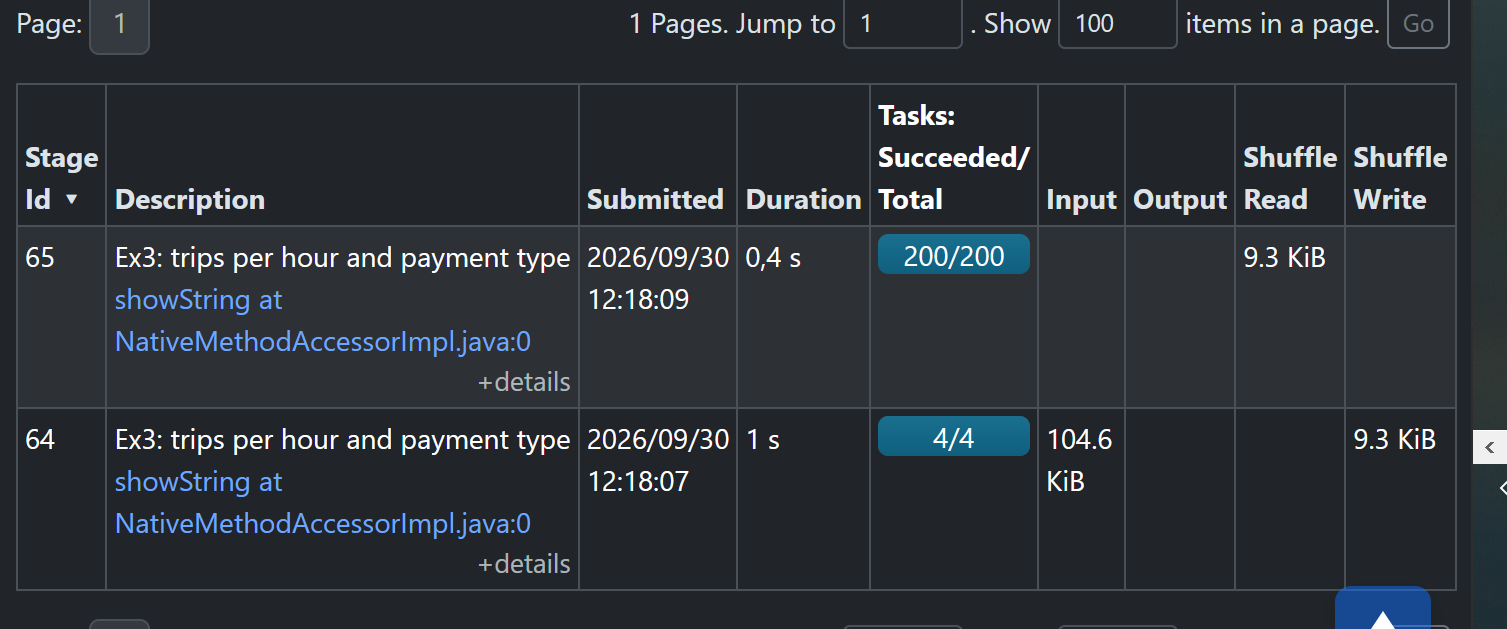


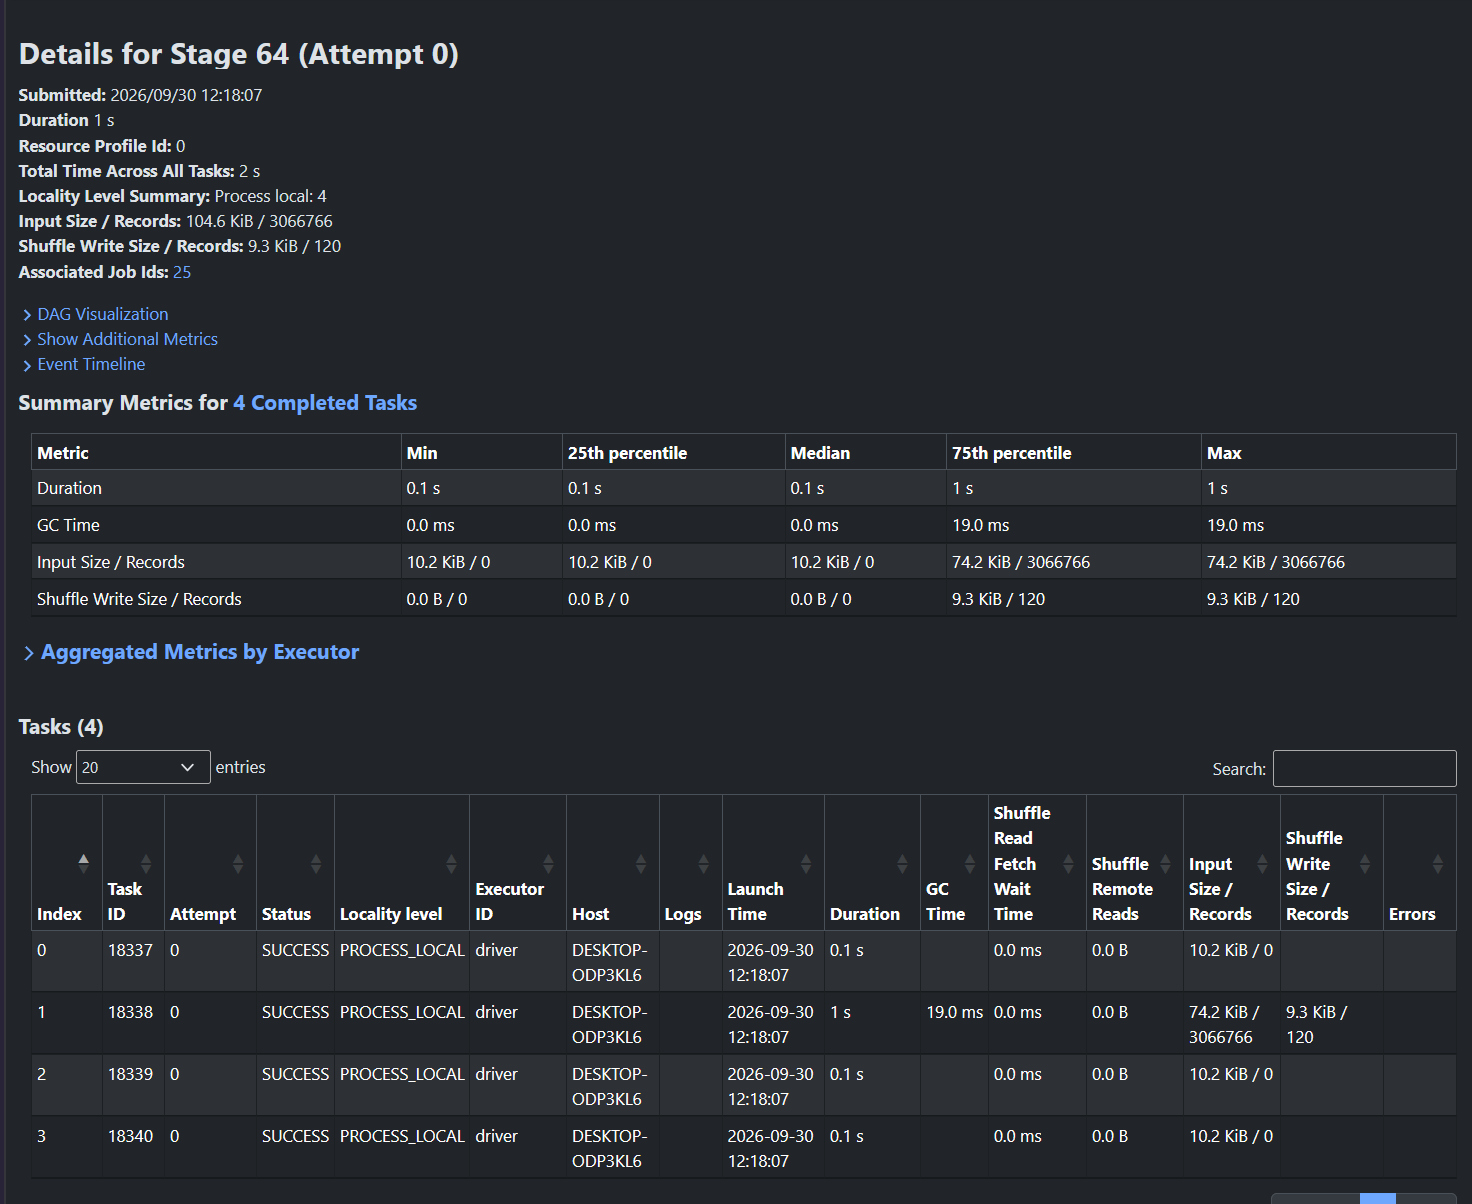

## Exercise 4 — Adaptive Query Execution

AQE re-plans a query *at runtime*, using statistics from completed stages instead of
estimates made before anything ran.

In [19]:
def build_query():
    """Build the query fresh.

    This has to be a function. A DataFrame caches its QueryExecution the first time it is
    planned, so reusing one object across a `spark.conf.set` gives you the *old* plan back
    and the comparison below silently shows no difference.
    """
    return (
        trips.filter(F.col("payment_type") == 2)  # a small slice
        .groupBy("pu_location_id")
        .agg(F.avg("fare_amount").alias("avg_fare"))
    )

In [20]:
plans = {}
for aqe in (False, True):
    spark.conf.set("spark.sql.adaptive.enabled", aqe)
    q = build_query()
    # Q4a asks you to compare the task counts of these two runs. Labelling them separately is
    # what makes them tellable apart in the UI.
    spark.sparkContext.setJobDescription(f"Ex4: avg fare by location (AQE {'on' if aqe else 'off'})")
    t0 = time.time()
    # collect() rather than a noop write: it runs *this* DataFrame's query execution, so the
    # plan we read back afterwards is the final adaptive one (`isFinalPlan=true`) rather than
    # the initial guess. The result is one row per pickup location — a couple of hundred.
    rows = q.collect()
    elapsed = time.time() - t0
    plans[aqe] = physical_plan(q)
    print(f"AQE {'on ' if aqe else 'off'}: {elapsed:5.2f} s, {len(rows)} rows")

AQE off:  1.19 s, 244 rows
AQE on :  0.82 s, 244 rows


In [21]:
for aqe, plan in plans.items():
    print(
        f"AQE {'on ' if aqe else 'off'}  "
        f"AdaptiveSparkPlan={'AdaptiveSparkPlan' in plan!s:<5}  "
        f"AQEShuffleRead={'AQEShuffleRead' in plan}"
    )

print()
print(plans[True][:1200])

AQE off  AdaptiveSparkPlan=False  AQEShuffleRead=False
AQE on   AdaptiveSparkPlan=True   AQEShuffleRead=True

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   ResultQueryStage 1
   +- *(2) HashAggregate(keys=[pu_location_id#25], functions=[avg(fare_amount#10)])
      +- AQEShuffleRead coalesced
         +- ShuffleQueryStage 0
            +- Exchange hashpartitioning(pu_location_id#25, 200), ENSURE_REQUIREMENTS, [plan_id=1552]
               +- *(1) HashAggregate(keys=[pu_location_id#25], functions=[partial_avg(fare_amount#10)])
                  +- *(1) Project [fare_amount#10, cast(PULocationID#7L as int) AS pu_location_id#25]
                     +- *(1) Filter (isnotnull(payment_type#9L) AND (cast(payment_type#9L as int) = 2))
                        +- *(1) ColumnarToRow
                           +- FileScan parquet [PULocationID#7L,payment_type#9L,fare_amount#10] Batched: true, DataFilters: [isnotnull(payment_type#9L), (cast(payment_type#9L as int) = 

**Q4a.** With AQE off the plan is a plain physical plan; with AQE on it is wrapped in an
`AdaptiveSparkPlan` node marked `isFinalPlan=true`. Confirm that above. Then look at the
task counts for each run in the Spark UI — how many shuffle partitions did each actually
use, and how does that compare to the `spark.sql.shuffle.partitions` you printed earlier?

Yes — AQE off gives a plain plan, AQE on is wrapped in AdaptiveSparkPlan isFinalPlan=true. spark.sql.shuffle.partitions is 200. Without AQE the reduce stage ran all 200 tasks (mostly empty). With AQE it ran just 1 task (stage 70, 6 ms, 12.1 KiB / 244 records). The shuffle still wrote 200 partitions, AQE only changed how many tasks read them. Also with AQE the query split into two jobs (27 and 28), because AQE waits for the map stage to finish before planning the next one.

**Q4b.** An `AQEShuffleRead` node only appears once AQE has actually *coalesced* something.
Find it in the plan text above and say what it did: how many partitions went in, how many
came out, and why AQE was able to make that call at runtime when the initial planner
could not.

AQEShuffleRead coalesced merged 200 partitions into 1. After the filter and partial aggregation, 3M rows became only 244 records (12.1 KiB), so there was no point in 200 tasks. The initial planner couldn't know this, it only has estimates before running. AQE sees the real shuffle size after the map stage and re-plans based on that. Result: 1.19 s → 0.82 s, same 244 rows.

**Q4c.** AQE has three main tricks: coalescing shuffle partitions, switching join
strategies, and splitting skewed partitions. Which one fired here, and how do you know?

Coalescing fired, the plan literally says AQEShuffleRead coalesced and tasks dropped from 200 to 1. Join switching couldn't happen because there's no join in this query. Skew splitting also didn't happen, there's no skewed in the plan. Side note: AQE didn't fix the input imbalance in stage 68 (one task read all 3M rows), because it only works at shuffle boundaries.

## Exercise 5 — Skew

Skew is when one partition holds far more data than the others. The stage cannot finish
until its slowest task does, so one fat partition stalls everything.

We build a deliberately skewed key and join on it.

In [22]:
# 90% of rows get key 0; the rest are spread over 1..99
skewed = trips.withColumn(
    "join_key",
    F.when(F.rand(seed=42) < 0.9, F.lit(0)).otherwise((F.rand(seed=7) * 99 + 1).cast("int")),
)

lookup = (
    spark.range(0, 100)
    .withColumnRenamed("id", "join_key")
    .withColumn("label", F.concat(F.lit("key_"), F.col("join_key")))
)

spark.sparkContext.setJobDescription("Ex5: row count per join key (confirm the skew)")
skewed.groupBy("join_key").count().orderBy(F.desc("count")).show(5)

+--------+-------+
|join_key|  count|
+--------+-------+
|       0|2759795|
|      10|   3220|
|      36|   3216|
|      23|   3199|
|      49|   3199|
+--------+-------+
only showing top 5 rows


In [23]:
spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)  # force a shuffle join

spark.sparkContext.setJobDescription("Ex5: skewed shuffle join (before mitigation)")

t0 = time.time()
(
    skewed.join(lookup, "join_key")
    .groupBy("label")
    .agg(F.avg("fare_amount"))
    .write.format("noop")
    .mode("overwrite")
    .save()
)
print(f"skewed shuffle join: {time.time() - t0:.2f} s")

skewed shuffle join: 4.84 s


Open the Spark UI for that job and look at the task durations in the join stage.

**Q5a.** What is the ratio of max task duration to median task duration? What does the task
duration histogram look like?

Max is 3 s, median is 11 ms, so the ratio is about 270×. The distribution is very lopsided: most tasks finish in 5–50 ms (min 5 ms, p25 7 ms, median 11 ms, p75 48 ms), and then there's one huge outlier, task 5 at 3 s. That task read 16.2 MiB / 2,759,796 rows (~90% of all data) and even spilled to disk (8.8 MiB), while the median task read 0 B. So the "histogram" is basically a big spike near zero plus one lonely bar far to the right, and the whole stage waited for that one task.

**Paste a screenshot of the task summary below.**

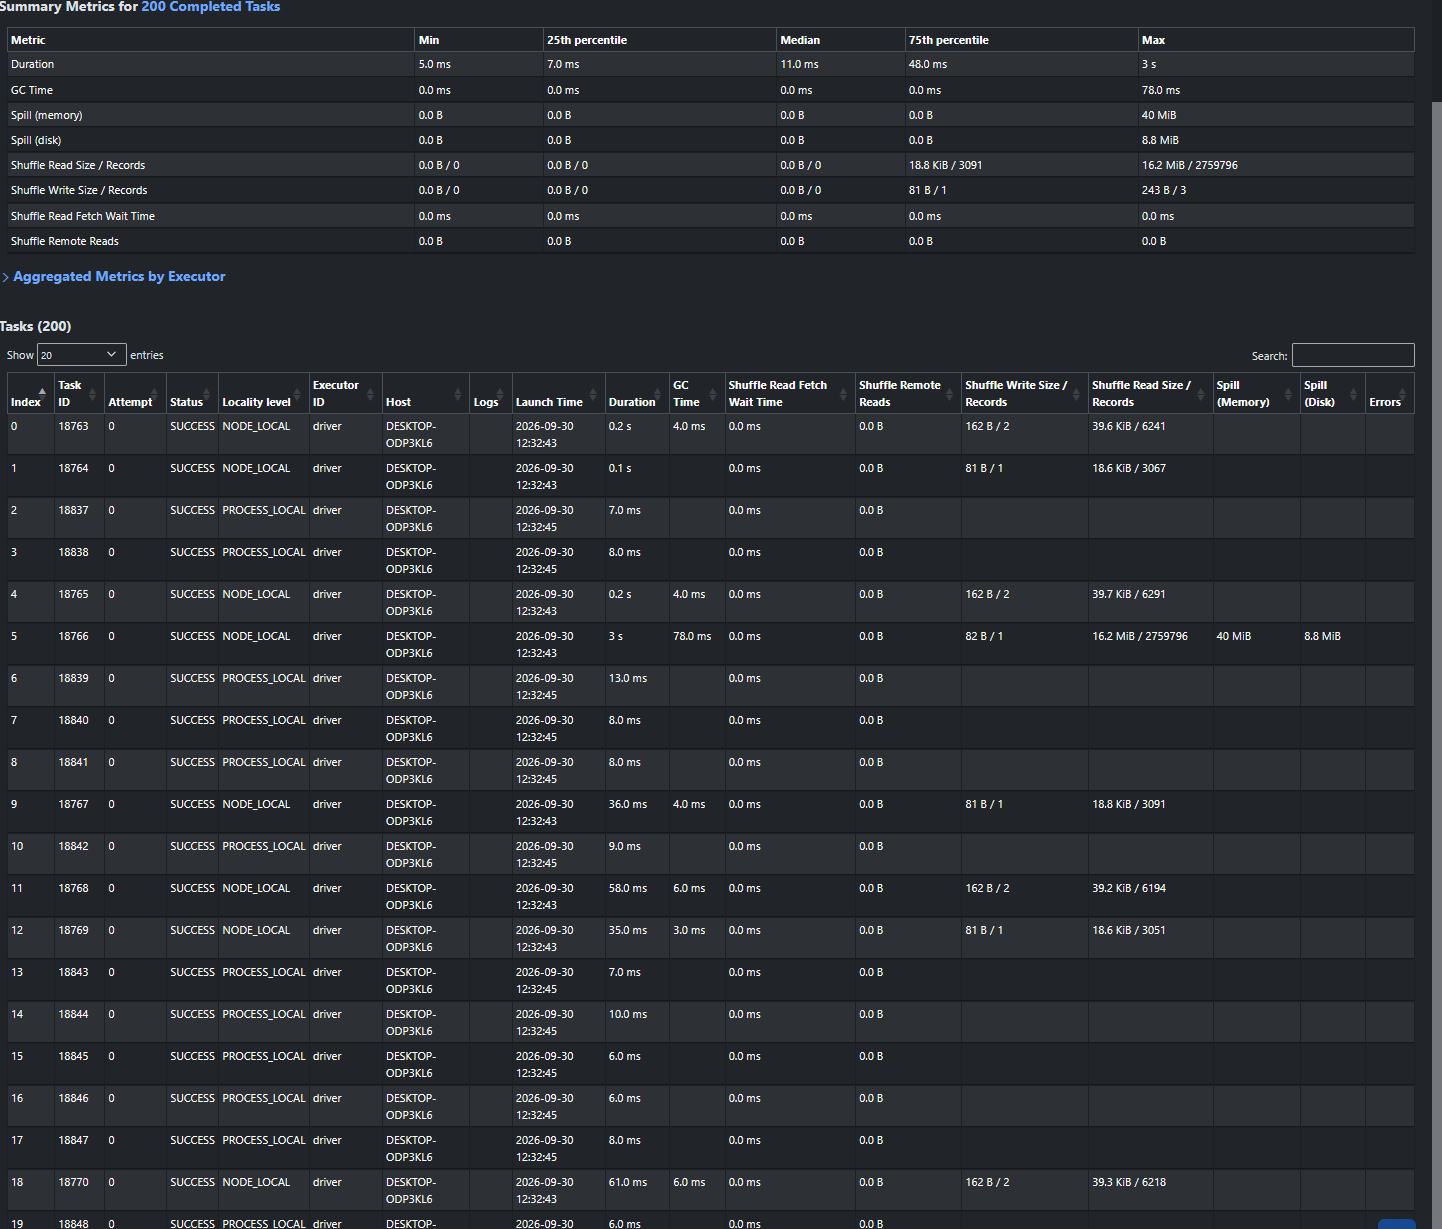

### Now fix it

Three options. Try at least one, measure it, and say why it worked.

1. **Broadcast the small side** — `lookup` has 100 rows. Broadcasting removes the shuffle
   entirely. Re-enable `autoBroadcastJoinThreshold`, or use `F.broadcast()`.
2. **Let AQE handle it** — turn adaptive execution back on and let it split the skewed
   partition.
3. **Salt the key** — add a random suffix to the hot key on the large side, replicate the
   small side across those salt values, join on the salted key.

In [28]:
from pyspark.sql import functions as F
# TODO: apply a mitigation and time it
# The label is already set so this run sits next to the un-mitigated one in the Spark UI,
# ready for the side-by-side comparison Q5b asks for.
spark.sparkContext.setJobDescription("Ex5: mitigated join")

t0 = time.time()
(
    skewed.join(F.broadcast(lookup), "join_key")
    .groupBy("label")
    .agg(F.avg("fare_amount"))
    .write.format("noop")
    .mode("overwrite")
    .save()
)
print(f"mitigated: {time.time() - t0:.2f} s")

mitigated: 0.99 s


**Q5b.** Which mitigation did you use, what was the speedup, and *why* did it work? Be
specific about what stopped happening.

I used broadcast (F.broadcast(lookup)). Skewed shuffle join: 4.84 s, broadcast: 0.99 s, so about 4.9× faster. The lookup has only 100 rows, so Spark sends a copy to every task (stage 82, 24 ms) and the big table doesn't need to be shuffled at all. What stopped happening: the big table's shuffle (shuffle write went from 18.1 MiB to 6.6 KiB), the whole 200-task join stage, and the 3 s straggler task that read 2.76M rows of the hot key and spilled 8.8 MiB to disk. The only shuffle left is the tiny one for groupBy("label") (stage 84, 0.2 s).

**Q5c.** Broadcast is the obvious fix here because the lookup table is tiny. Describe a
situation where broadcast is not available and salting is the only option left.

When both sides are big. For example, joining trips with another huge table (like GPS pings or payment events per trip) where one key is hot on both sides. Broadcasting either table would mean copying gigabytes to every executor, and it would run out of memory (Spark also has a size limit on broadcasts). Another case is an outer join where the small table is on the side that has to be preserved, like the left side of a LEFT JOIN: Spark can't broadcast that side. Salting still works in both cases, because it just splits the hot key into more partitions.

In [29]:
# restore defaults
spark.conf.unset("spark.sql.autoBroadcastJoinThreshold")
spark.conf.set("spark.sql.adaptive.enabled", True)

## Appendix — where does a table actually live?

The catalog / database / table hierarchy, what `metastore_db/` and `spark-warehouse/` each hold,
and what changes when you point Spark at a different catalog, now live in their own notebook:

**[`appendix_catalogs.ipynb`](appendix_catalogs.ipynb)**

Not marked, and it does not affect the rubric — but it is the local counterpart to Unity Catalog,
and it explains the two directories this lab leaves in your repo root. Run it after this notebook
(or on its own; it builds what it needs).

## Wrap-up

**Q6.** You have five exercises' worth of measurements from your own machine. If you had to
put this job into production tomorrow, what one thing would you change about how it runs —
and which single measurement from above drove that decision? Name the number.

I'd always broadcast small dimension tables instead of shuffle-joining them. The number: in Ex5 one task took 3 s vs an 11 ms median (~270×) because it got 2.76M rows of one key, and broadcasting cut the job from 4.84 s to 0.99 s.

## Done

Submit `L2_<your-surname>.ipynb` with every *(replace this line)* filled in and both
screenshots in place.

In [30]:
# This also shuts down the Spark UI, so finish exercises 3 and 5 before running it.
spark.stop()